In [168]:
import numpy as np
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 30)

In [169]:
df = pd.read_csv("../data/raw/auto_imports.csv")

In [170]:
df.head()

,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.60,168.80,64.10,48.80,2548,dohc,four,130,mpfi,3.47,2.68,9.00,111,5000,21,27,13495
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
1,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
2,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
3,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
4,2,?,audi,gas,std,two,sedan,fwd,front,99.8,177.3,66.3,53.1,2507,ohc,five,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250


In [171]:
column_names = [
    'symboling',
    'normalized_losses',
    'make',
    'fuel_type',
    'aspiration',
    'num_of_doors',
    'body_style',
    'drive_wheels',
    'engine_location',
    'wheel_base',
    'length',
    'width',
    'height',
    'curb_weight',
    'engine_type',
    'num_of_cylinders',
    'engine_size',
    'fuel_system',
    'bore',
    'stroke',
    'compression_ratio',
    'horsepower',
    'peak_rpm',
    'city_mpg',
    'highway_mpg',
    'price'
]

In [172]:
df = pd.read_csv("../data/raw/auto_imports.csv", header=None, na_values="?", names=column_names)

df.shape

(201, 26)

In [173]:
df.head()

,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,height,curb_weight,engine_type,num_of_cylinders,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450


In [174]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized_losses  164 non-null    float64
 2   make               201 non-null    str    
 3   fuel_type          201 non-null    str    
 4   aspiration         201 non-null    str    
 5   num_of_doors       199 non-null    str    
 6   body_style         201 non-null    str    
 7   drive_wheels       201 non-null    str    
 8   engine_location    201 non-null    str    
 9   wheel_base         201 non-null    float64
 10  length             201 non-null    float64
 11  width              201 non-null    float64
 12  height             201 non-null    float64
 13  curb_weight        201 non-null    int64  
 14  engine_type        201 non-null    str    
 15  num_of_cylinders   201 non-null    str    
 16  engine_size        201 non-null    in

In [175]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
symboling,201.0,0.840796,1.254802,-2.00,0.00,1.00,2.00,3.00
normalized_losses,164.0,122.000000,35.442168,65.00,94.00,115.00,150.00,256.00
wheel_base,201.0,98.797015,6.066366,86.60,94.50,97.00,102.40,120.90
length,201.0,174.200995,12.322175,141.10,166.80,173.20,183.50,208.10
width,201.0,65.889055,2.101471,60.30,64.10,65.50,66.60,72.00
height,201.0,53.766667,2.447822,47.80,52.00,54.10,55.50,59.80
curb_weight,201.0,2555.666667,517.296727,1488.00,2169.00,2414.00,2926.00,4066.00
engine_size,201.0,126.875622,41.546834,61.00,98.00,120.00,141.00,326.00
bore,197.0,3.330711,0.270793,2.54,3.15,3.31,3.59,3.94
stroke,197.0,3.256904,0.319256,2.07,3.11,3.29,3.41,4.17


In [176]:
df.describe(include="object").T

,count,unique,top,freq
make,201,22,toyota,32
fuel_type,201,2,gas,181
aspiration,201,2,std,165
num_of_doors,199,2,four,113
body_style,201,5,sedan,94
drive_wheels,201,3,fwd,118
engine_location,201,2,front,198
engine_type,201,6,ohc,145
num_of_cylinders,201,7,four,157
fuel_system,201,8,mpfi,92


## 3. EDA

### 3.1 Missing Values

In [177]:
df.isnull().sum().sort_values(ascending=False)

normalized_losses    37
stroke                4
bore                  4
peak_rpm              2
horsepower            2
num_of_doors          2
symboling             0
make                  0
fuel_type             0
aspiration            0
wheel_base            0
engine_location       0
drive_wheels          0
body_style            0
length                0
width                 0
height                0
curb_weight           0
fuel_system           0
engine_size           0
num_of_cylinders      0
engine_type           0
compression_ratio     0
city_mpg              0
highway_mpg           0
price                 0
dtype: int64

In [178]:
# Haddle numerical column missing values
for col in ['bore', 'stroke', 'horsepower', 'peak_rpm', 'normalized_losses']:
    df[col] = df[col].fillna(df[col].median())

In [179]:
# Handle categorical column missing values
df["num_of_doors"] = df["num_of_doors"].fillna(df["num_of_doors"].mode())

In [180]:
df.isnull().sum()

symboling            0
normalized_losses    0
make                 0
fuel_type            0
aspiration           0
num_of_doors         2
body_style           0
drive_wheels         0
engine_location      0
wheel_base           0
length               0
width                0
height               0
curb_weight          0
engine_type          0
num_of_cylinders     0
engine_size          0
fuel_system          0
bore                 0
stroke               0
compression_ratio    0
horsepower           0
peak_rpm             0
city_mpg             0
highway_mpg          0
price                0
dtype: int64

### 3.2 Outliers Detection

In [181]:
numerical_col = df.select_dtypes(include=["int", "float"]).columns
numerical_col

Index(['symboling', 'normalized_losses', 'wheel_base', 'length', 'width',
       'height', 'curb_weight', 'engine_size', 'bore', 'stroke',
       'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg',
       'highway_mpg', 'price'],
      dtype='str')

In [182]:
categorical_col = df.select_dtypes(include="object").columns
categorical_col

Index(['make', 'fuel_type', 'aspiration', 'num_of_doors', 'body_style',
       'drive_wheels', 'engine_location', 'engine_type', 'num_of_cylinders',
       'fuel_system'],
      dtype='str')

In [183]:
for col in numerical_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    upper_limit = Q3 + IQR*1.5
    lower_limit = Q1 - IQR*1.5

    df[col] = df[col].clip(lower_limit, upper_limit)

### 3.3 Find relationships target variables

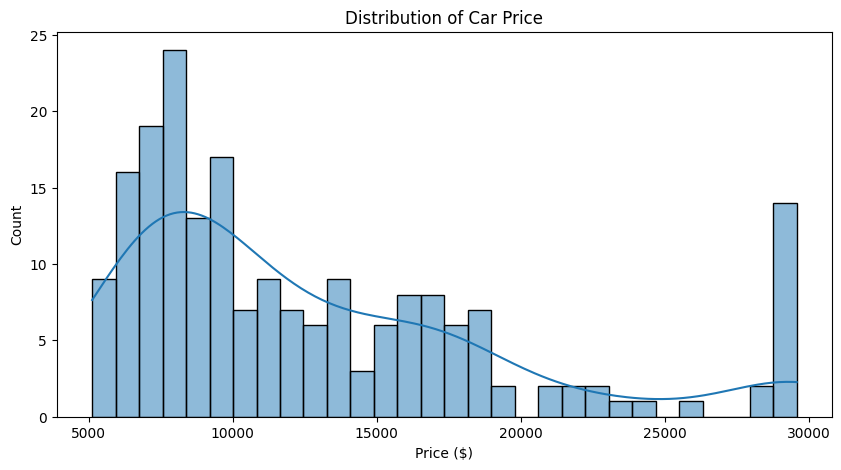

Skewness: 1.2319392399317273


In [184]:
# Target variable distribution
plt.figure(figsize=(10,5))
sns.histplot(df['price'], kde=True, bins=30)
plt.title('Distribution of Car Price')
plt.xlabel('Price ($)')
plt.savefig('../images/eda_plots/price_distribution.png')
plt.show()

print("Skewness:", df['price'].skew())

### 3.4 Numerial Feature Distribution

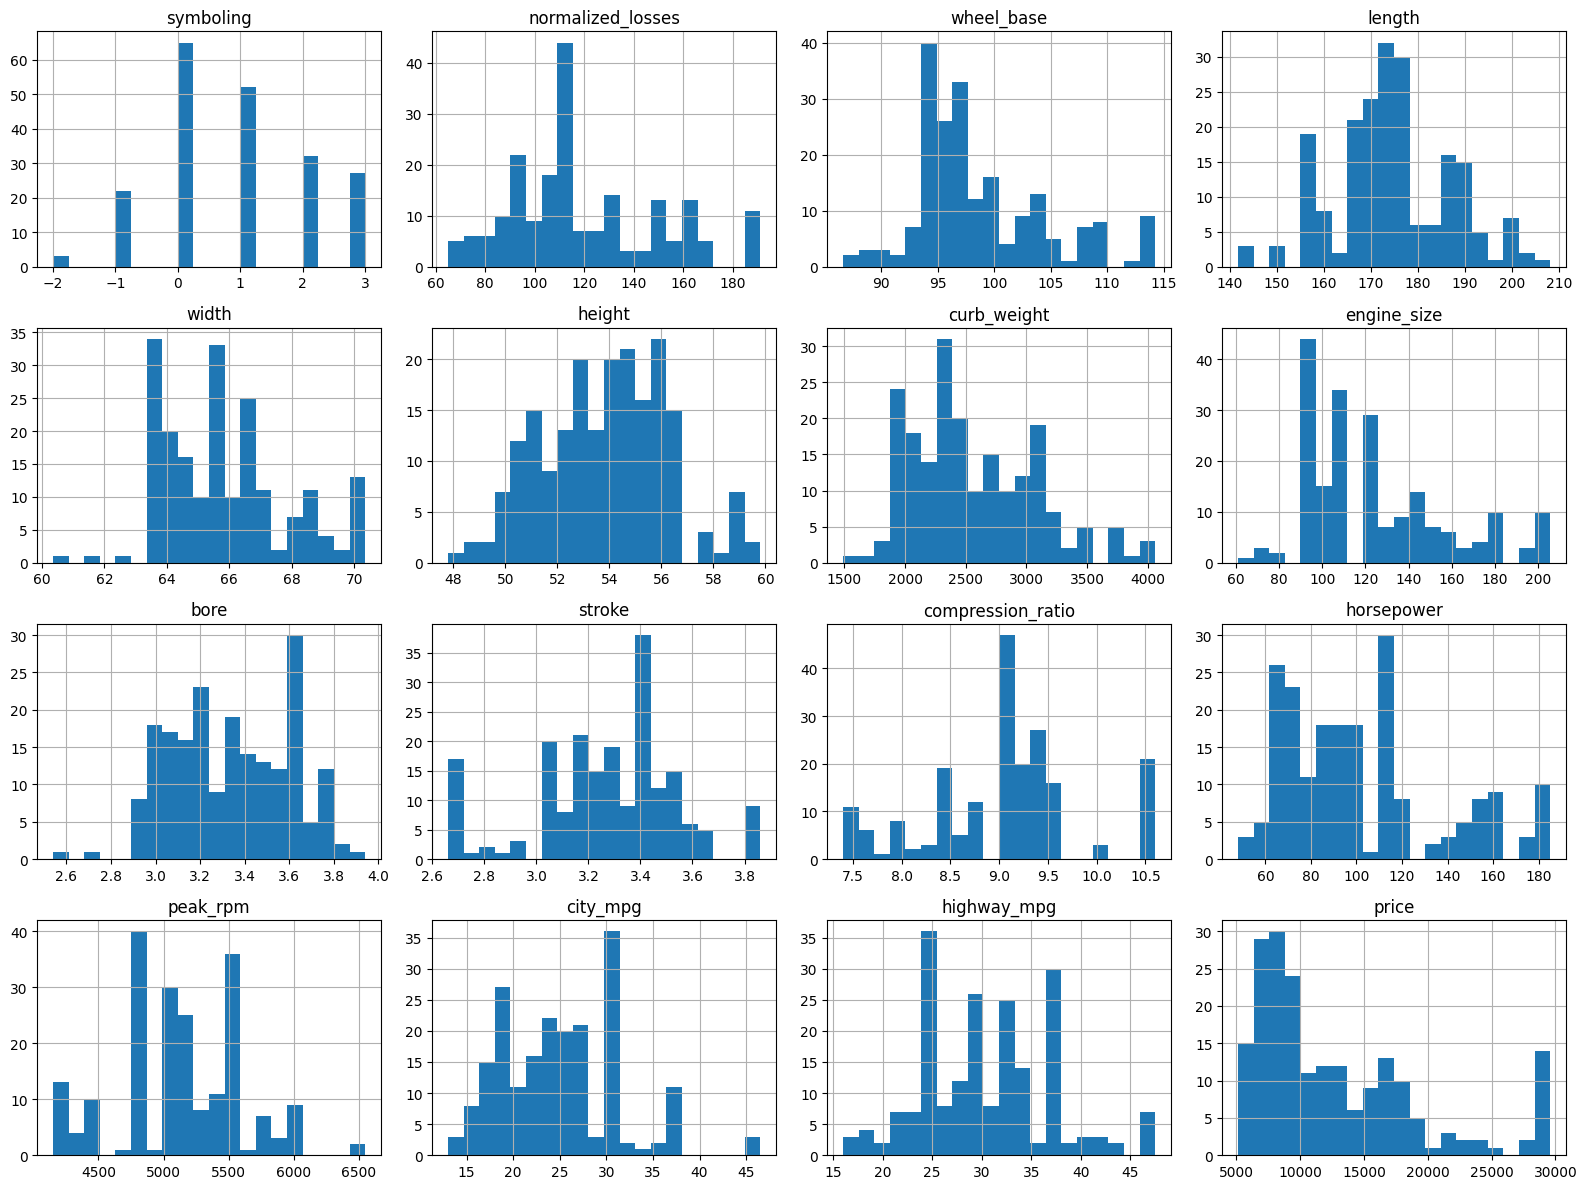

In [185]:
num = numerical_col.drop("price")
df[numerical_col].hist(bins=20, figsize=(16, 12))
plt.tight_layout()
plt.savefig(f"../images/eda_plots/numerical_feature_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### 3.5 Categorical feature disturibution

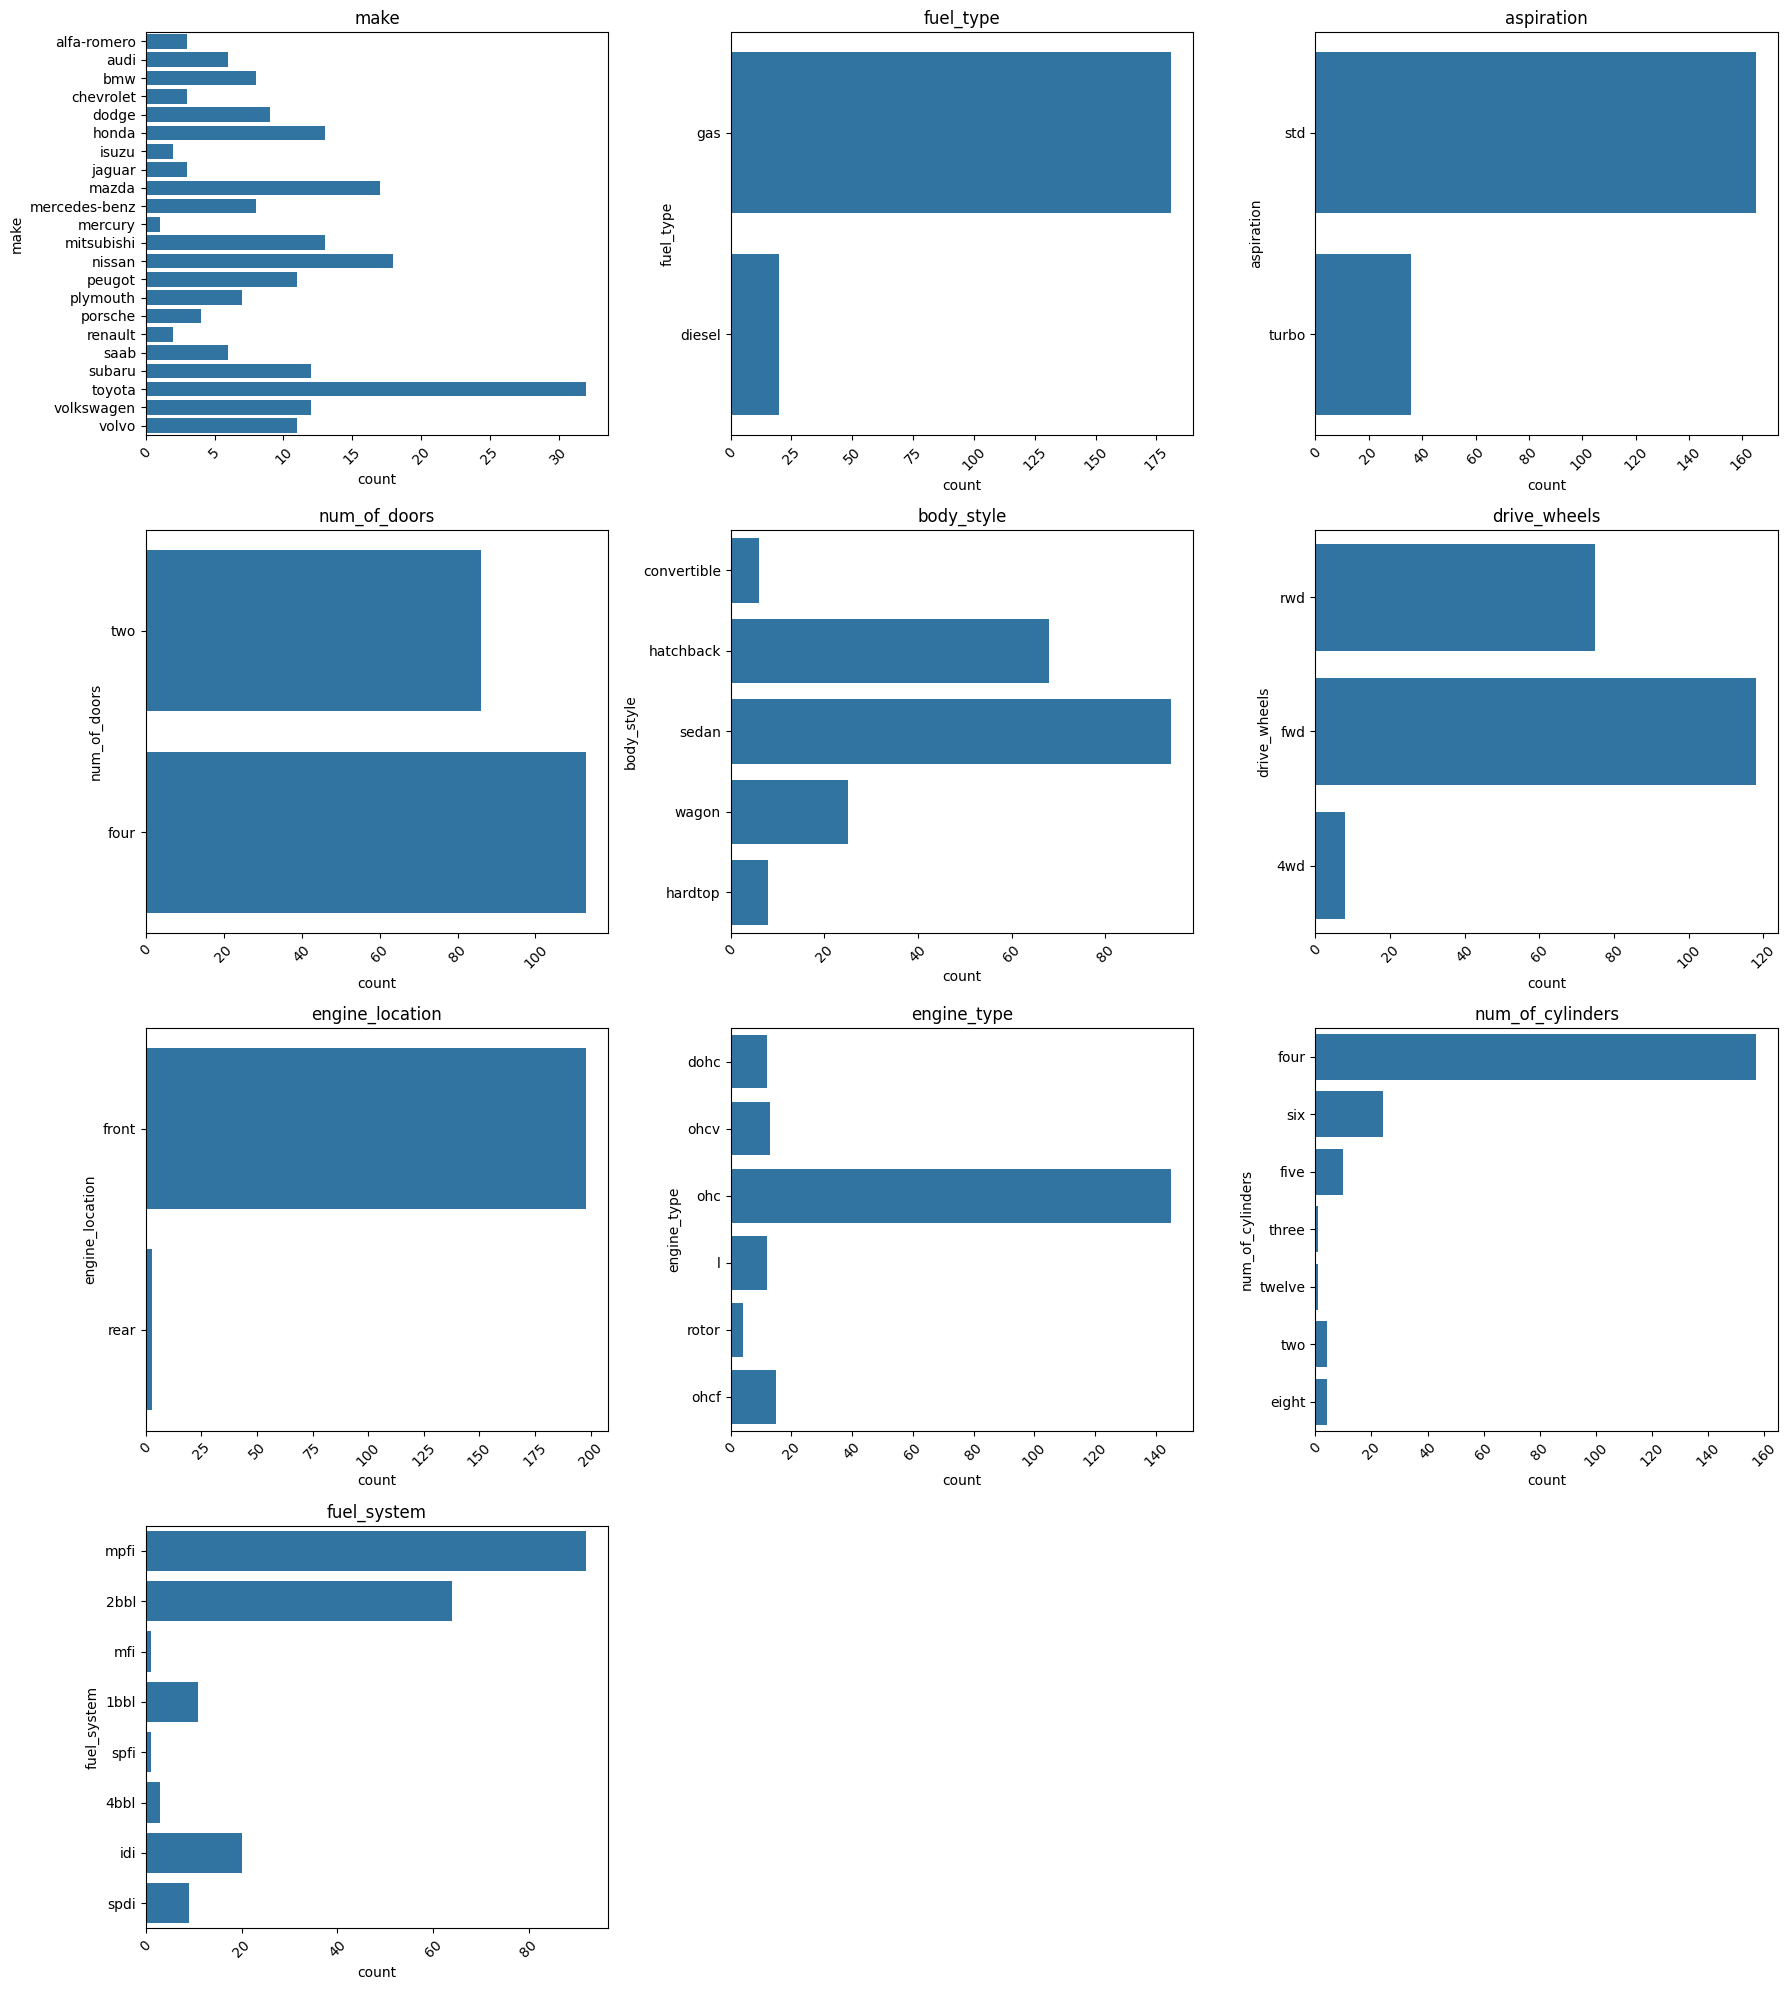

In [186]:
import math

n_cols = 3
n_rows = math.ceil(len(categorical_col) / n_cols)

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(categorical_col, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.countplot(data=df, y=col,)
    plt.title(col)
    plt.xticks(rotation=45)

plt.savefig("../images/eda_plots/categorical_feature.png")
plt.tight_layout()
plt.show()

### 3.6 Numerical Columns vs Target Columns

#### Symboling Scale

| Symboling | Insurance Risk Rating|
|-----------:|----------------|
| -3 | Very Safe (Lowest Risk) |
| -2 | Safe |
| -1 | Slightly Safe |
| 0 | Average Risk |
| 1 | Slightly Risky |
| 2 | Risky |
| 3 | Very Risky (Highest Risk) |

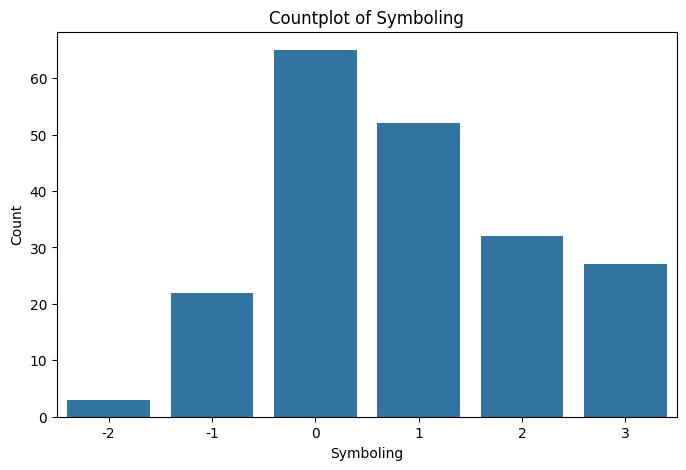

In [187]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="symboling")
plt.title("Countplot of Symboling")
plt.xlabel("Symboling")
plt.ylabel("Count")
plt.savefig("../images/eda_plots/Countplot_of_Symboling")
plt.show()

### 3.7 Correlation with price (numerical features)

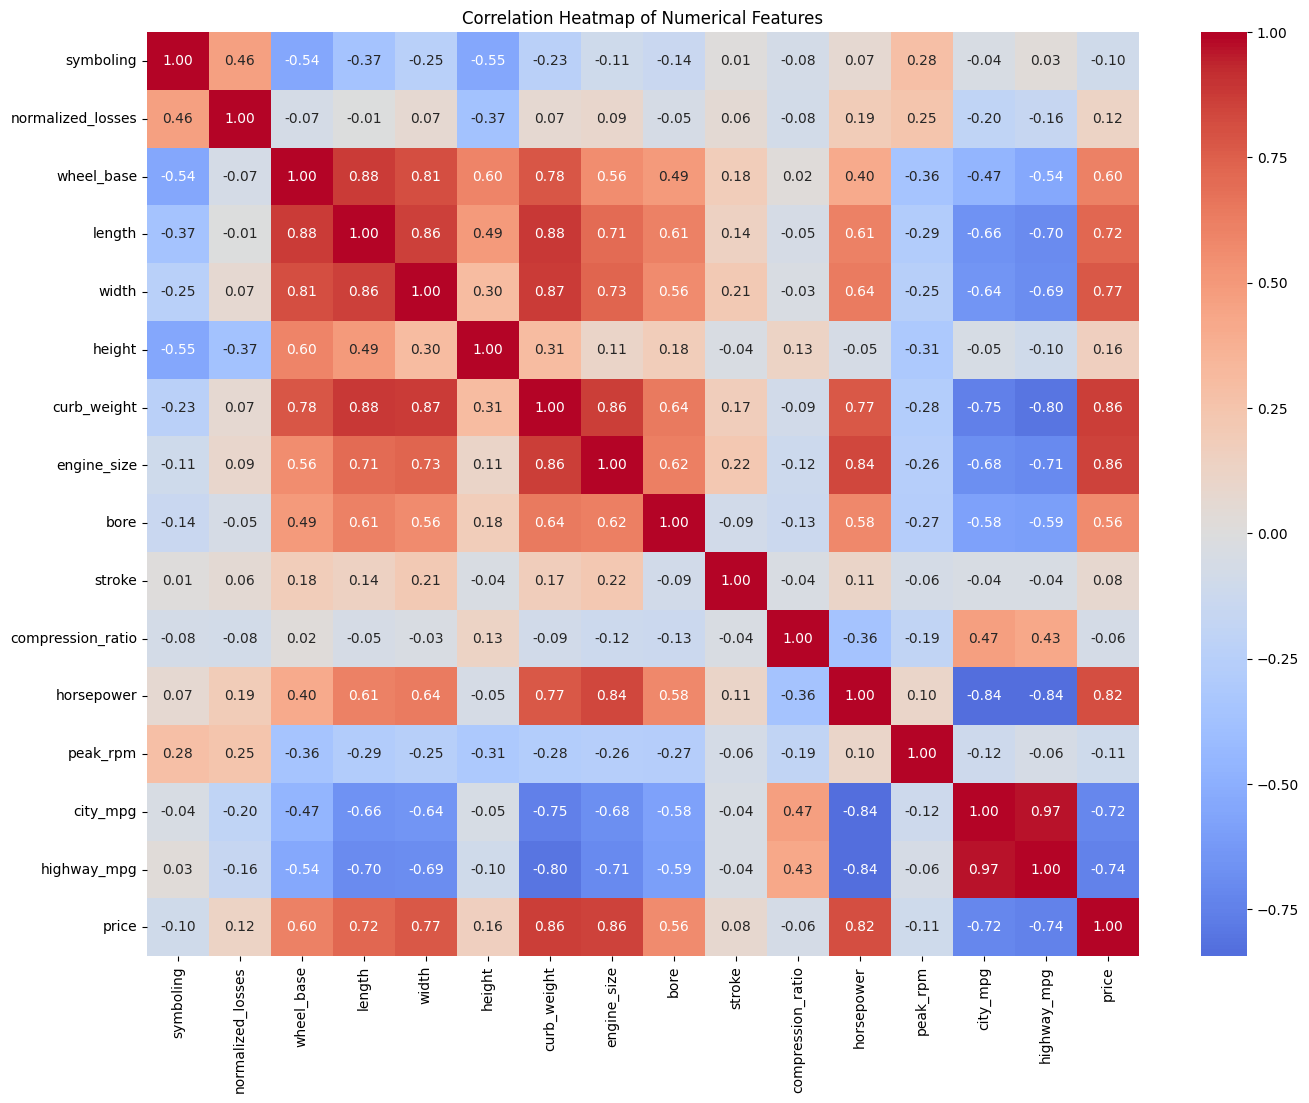

price                1.000000
curb_weight          0.864556
engine_size          0.855664
horsepower           0.816135
width                0.772948
length               0.722659
wheel_base           0.604694
bore                 0.562902
height               0.161092
normalized_losses    0.124567
stroke               0.077342
compression_ratio   -0.061965
symboling           -0.095307
peak_rpm            -0.108191
city_mpg            -0.719705
highway_mpg         -0.742944
Name: price, dtype: float64


In [188]:
plt.figure(figsize=(16,12))
corr = df[numerical_col].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numerical Features')
plt.savefig('../images/correlation_heatmap.png')
plt.show()

# Correlation with target specifically, sorted
print(corr['price'].sort_values(ascending=False))

Observe each scatter plot carefully.

Typical findings:

- Engine Size → Strong Positive Relationship
- Horsepower → Strong Positive Relationship
- Curb Weight → Strong Positive Relationship
- Width → Positive Relationship
- Wheel Base → Moderate Positive Relationship
- Highway MPG → Negative Relationship
- City MPG → Negative Relationship

These features are likely to become important predictors in the Machine Learning model.

### 3.8 Pairpolt - Top Numerical Features

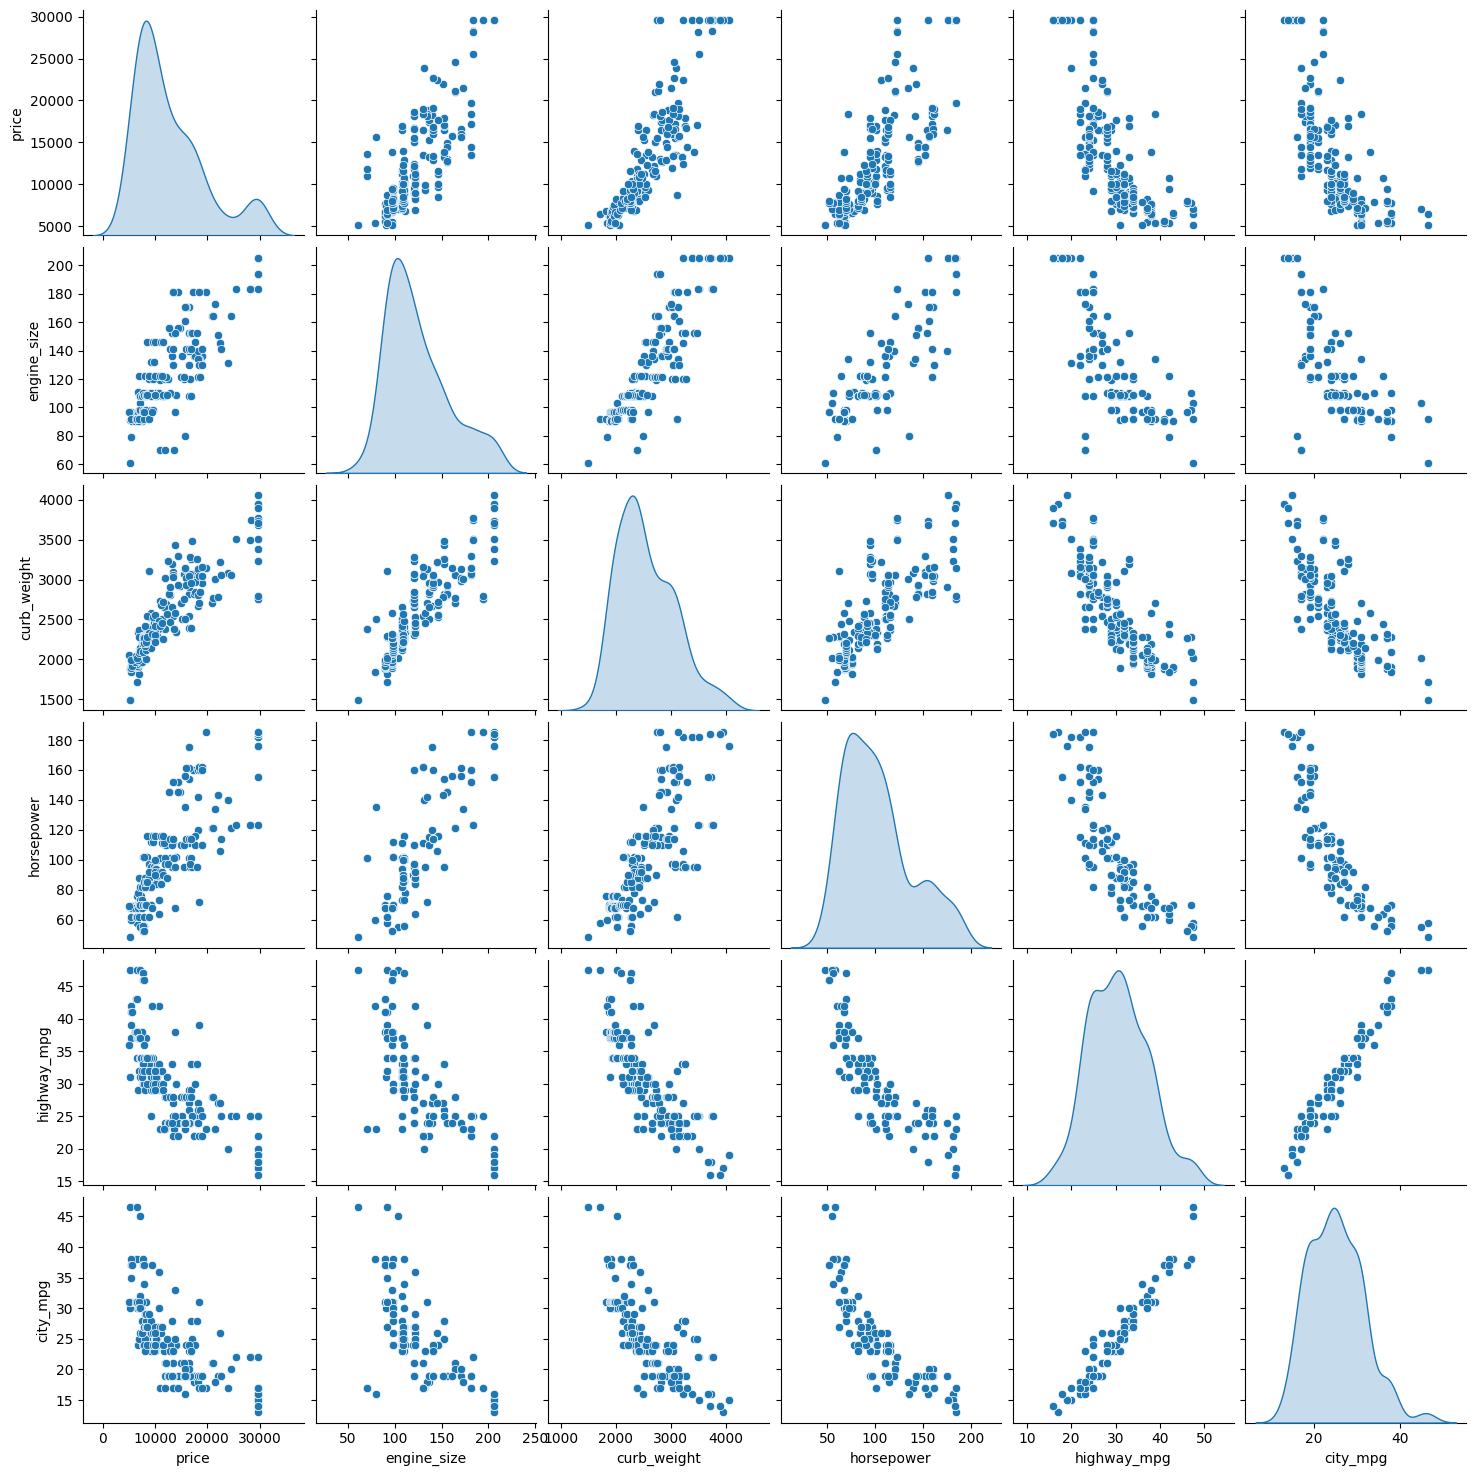

In [189]:
top_features = ['price', 'engine_size', 'curb_weight', 'horsepower', 'highway_mpg', 'city_mpg']
sns.pairplot(df[top_features], diag_kind='kde')
plt.savefig("../images/pairplot_with_top_feature.png")
plt.show()

### 3.9 Bivariate Analysis in categorical vs Price

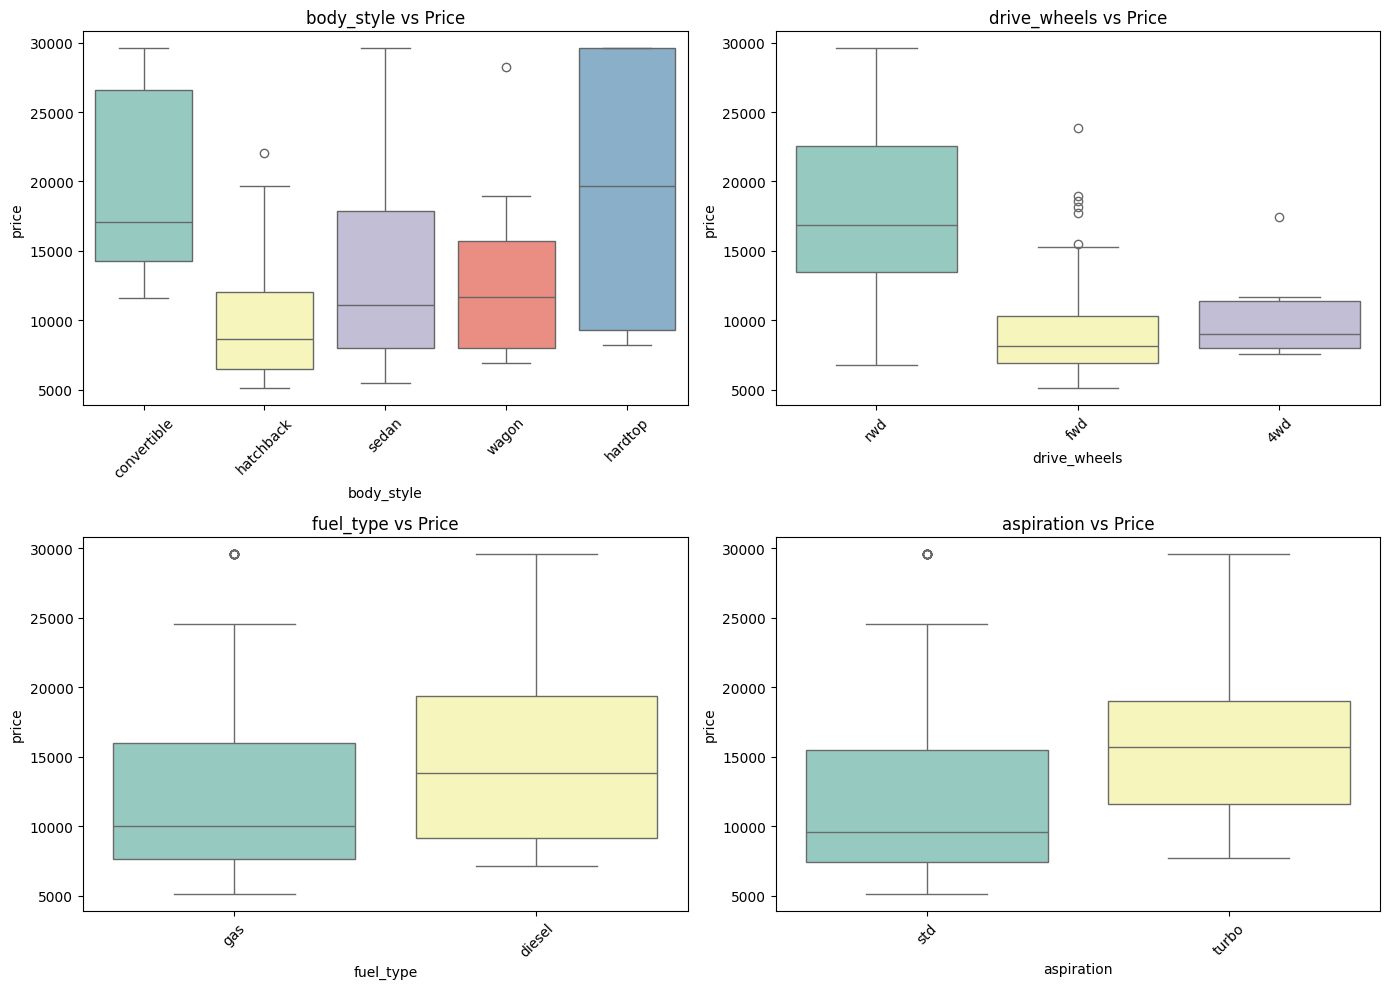

In [190]:
categorical_feature = ['body_style', 'drive_wheels', 'fuel_type', 'aspiration']

plt.figure(figsize=(14, 10))

for i, col in enumerate(categorical_feature, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x=col, y='price', palette="Set3")
    plt.title(f'{col} vs Price')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../images/eda_plots/categorical_vs_price_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

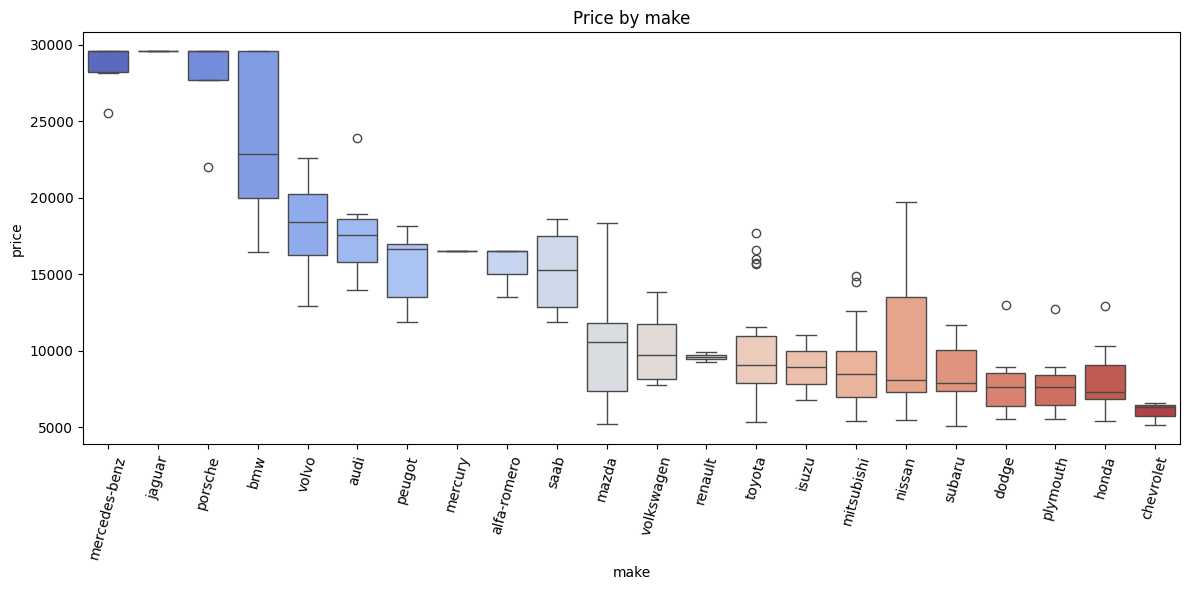

In [191]:
plt.figure(figsize=(12, 6))
order = df.groupby('make')['price'].median().sort_values(ascending=False).index
sns.boxplot(x='make', y='price', data=df, order=order, palette='coolwarm')
plt.xticks(rotation=75)
plt.title('Price by make')
plt.tight_layout()
plt.savefig("../images/eda_plots/make_vs_price.png")
plt.show()

## 4. Data Preprossecing

### 4.1 Data Encoding

In [ ]:
mapping = {'two':2,'three':3,'four':4,'five':5,'six':6,'eight':8,'twelve':12}
df["num_of_cylinders"] = df["num_of_cylinders"].map(mapping)
df["num_of_doors"] = df["num_of_doors"].map(mapping)
df.head()

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer.Replace or remove non-finite values or cast to an integer typethat supports these values (e.g. 'Int64')

In [193]:
print("Numerical Column : ", numerical_col)
print("Categorical Column : ", categorical_col)

Numerical Column :  Index(['symboling', 'normalized_losses', 'wheel_base', 'length', 'width',
       'height', 'curb_weight', 'engine_size', 'bore', 'stroke',
       'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg',
       'highway_mpg', 'price'],
      dtype='str')
Categorical Column :  Index(['make', 'fuel_type', 'aspiration', 'num_of_doors', 'body_style',
       'drive_wheels', 'engine_location', 'engine_type', 'num_of_cylinders',
       'fuel_system'],
      dtype='str')
